### I Hyperparameters

In [9]:
import shutil

# actor
ACTOR_HIDDEN_DIM = 128
ACTOR_HIDDEN_LAYER_COUNT = 1
ACTOR_LR = 1e-4

# critic
CRITIC_HIDDEN_DIM = 128
CRITIC_HIDDEN_LAYER_COUNT = 1
CRITIC_LR = 1e-3


### II Initialization

#### 1. Environment

In [10]:
from environment import Environment

# import random
# seed = random.randint(0, 100000000)
# random.seed(seed)

env = Environment(
    render_mode="rgb_array",
    random_seed=49206172,
    # ue_count=40,
    # cluster_count=4,
    # uav_count=3,
    # fog_count=3,
    # area_size=(1000,1000)
)

# print("seed:", seed)

env.reset()

agent_count = len(env.uavs)
state_dim = env.observation_space.shape[1]
action_dim = env.action_space.shape[1]

Show environment

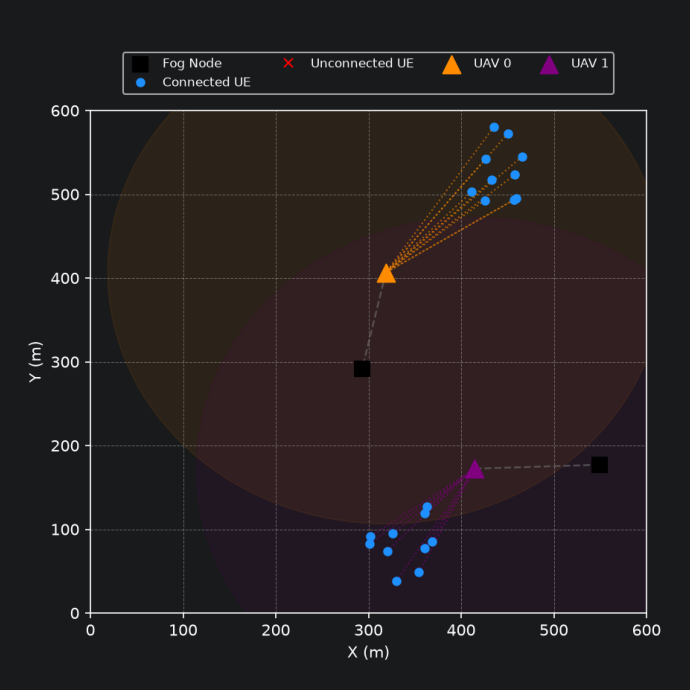

In [11]:
from matplotlib import pyplot as plt

img = env.render()
if img is not None:
    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

#### 2. Algorithm

In [12]:
from algorithm import Algorithm
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

algorithm = Algorithm(
    algorithm="MADDPG",
    agent_count=agent_count,
    state_dim=state_dim,
    action_dim=action_dim,
    actor_hidden_dim=ACTOR_HIDDEN_DIM,
    critic_hidden_dim=CRITIC_HIDDEN_DIM,
    actor_hidden_layer_count=ACTOR_HIDDEN_LAYER_COUNT,
    critic_hidden_layer_count=CRITIC_HIDDEN_LAYER_COUNT,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    device=device,
)


### III Training

Hyperparameters

In [13]:
BATCH_SIZE = 128
EPISODE_COUNT = 400
TRAIN_INTERVAL = 10

Training loop

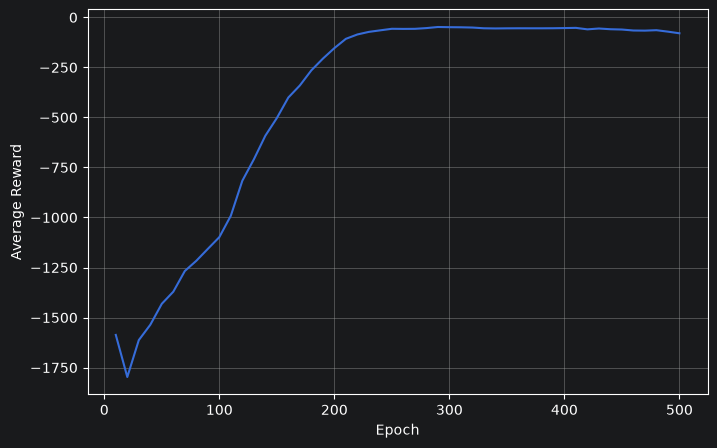

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

PRINT_INTERVAL = 10
EPISODE_SIZE = 200

total_steps = 0
score_history = []

avg_scores = []  # y
episodes_recorded = []  # x
fig, ax = plt.subplots(figsize=(8, 5))

for episode in range(1, EPISODE_COUNT + 1):
    score = 0.0
    for step in range(1, EPISODE_SIZE + 1):
        total_steps += 1
        reward, _, _ = algorithm.explore(env=env)
        score += float(np.mean(reward))
        if total_steps % TRAIN_INTERVAL == 0:
            algorithm.train()

    score_history.append(score)
    avg_score = float(np.mean(score_history[-100:]))
    if episode % PRINT_INTERVAL == 0 and episode > 0:
        avg_scores.append(avg_score)
        episodes_recorded.append(episode)

        ax.clear()
        ax.plot(episodes_recorded, avg_scores)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Average Reward')
        ax.grid(True)

        clear_output(wait=True)
        display(fig)
plt.close()

### IV Check result

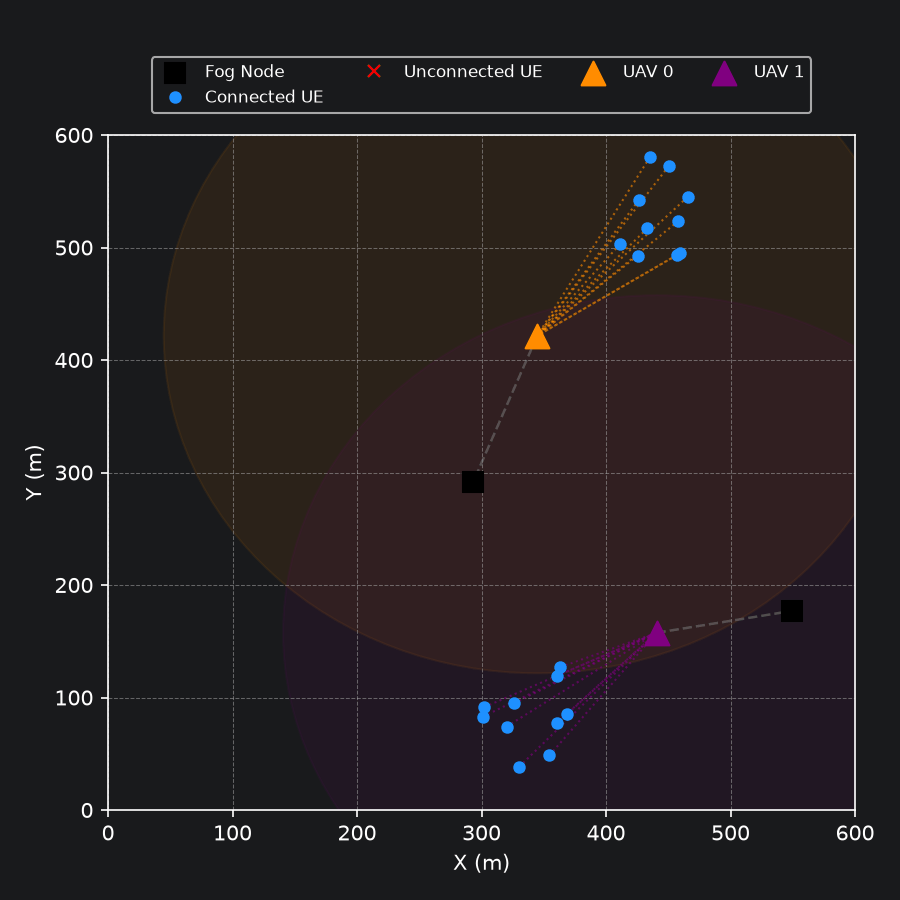

In [15]:
from IPython.display import Image, display
import imageio.v2 as imageio
import os

frames = []
max_eval_steps = 500
done = False
step = 0

while not done and step < max_eval_steps:
    _, done, image = algorithm.explore(
        env=env,
        render=True,
        evaluate=True
    )

    if image is not None:
        frames.append(image.copy())

    step += 1

result_dir = "results"

os.makedirs(result_dir, exist_ok=True)
gif_path = os.path.join(result_dir, "evaluation.gif")
imageio.mimsave(gif_path, frames, fps=30)

display(Image(filename=gif_path))

### V Save model

In [16]:
algorithm.save_checkpoint(os.path.join(result_dir, "checkpoint"))